In [3]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp

### Parameter Values

- $\alpha$: infection rate from living hosts
- $\beta$: death rate from disease
- $\gamma$: infection rate from deceased hosts
- $\delta$: death rate of fungus in dead hosts
- $\zeta$: recovery rate (should have something to do with temperature)
- $\pi$: natural birth/death rate

If we want to add an equation for symptomatic (split $I$ into $I_1$ and $I_2$), we would have

- $\frac{dI_1}{dt} = \alpha_1 SI_1 + \alpha_2 SI_2 + \gamma R_1 - \beta_1 I_1$
- $\frac{dI_2}{dt} = \beta_1 I_1 - \beta_2 I_2$

where $\alpha_1 > \alpha_2$. Then $\frac{dR_1}{dt}$ would change $\beta I$ to $\beta_2 I_2$.

In [ ]:
# SIRR model  (FIX PARAMETERS WHEN WE GET THEM)
def disease_model(t, y, params=[.003, .001, .005, .005, .004, .005]):
    S, I, R1, R2 = y    # unpack variables
    alpha, beta, gamma, delta, zeta, pi = params
    
    # define system of differential equations
    dS = -alpha*S*I - gamma*S*R1 + zeta*I + pi*S
    dI = alpha*S*I + gamma*S*R1 - beta*I - zeta*I
    dR1 = beta*I - delta*R1
    dR2 = delta*R1

    return [dS, dI, dR1, dR2]

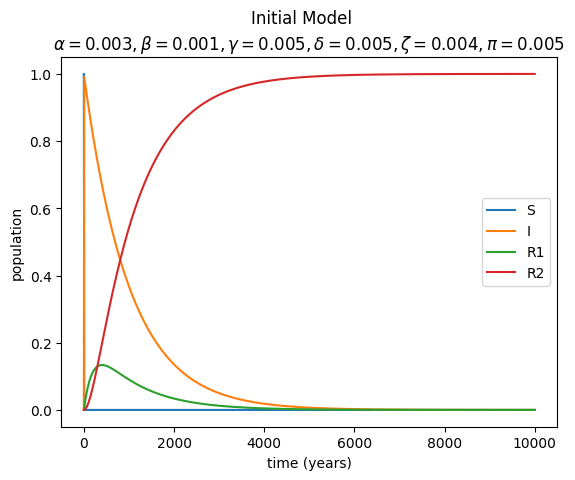

In [155]:
initial = [4000, 1, 0, 0]
alpha, beta, gamma, delta, zeta, pi = .003, .001, .005, .005, .004, .005
N = sum(initial)
sol = solve_ivp(disease_model, t_span=[0, 10000], y0=initial, t_eval=np.linspace(0, 10000, 1000), args=[[alpha, beta, gamma, delta, zeta, pi]])
t_vals = np.linspace(0, 10000, 1000)

plt.plot(t_vals, sol.y[0] / N, label='S')
plt.plot(t_vals, sol.y[1] / N, label="I")
plt.plot(t_vals, sol.y[2] / N, label="R1")
plt.plot(t_vals, sol.y[3] / N, label="R2")
plt.suptitle("Initial Model")
plt.title(fr"$\alpha = {alpha}, \beta = {beta}, \gamma = {gamma}, \delta = {delta}, \zeta = {zeta}, \pi = {pi}$")
plt.xlabel("time (years)")
plt.ylabel("population")
# plt.ylim(0, 100)
plt.legend()
plt.savefig("figures/InitialModel2_steady.png")

#### Try it with periodic infection rate to reflect weather patterns

--> modify original model to have periodic motion

From "Seasonal infectious disease epidemiology" (Grassly and Fraser, 2006)

Seasonal transmission often assumed sinusoidal

$$ \beta(t)=\beta(1 + \sigma\cos(2\pi t)) $$

In [129]:
# SIRR model  (FIX PARAMETERS WHEN WE GET THEM)
def disease_model_periodic(t, y, params=[.003, .001, .005, .005, .004, .005]):
    S, I, R1, R2 = y    # unpack variables
    alpha1, beta, gamma, delta, zeta, pi = params

    # introduce periodic seasonal transmission
    sigma = 5    # amplitude of seasonal variation in transmission
    alpha = alpha1*(1 + sigma*np.cos(2*np.pi*t))
    
    # define system of differential equations
    dS = -alpha*S*I - gamma*S*R1 + zeta*I
    dI = alpha*S*I + gamma*S*R1 - beta*I - zeta*I
    dR1 = beta*I - delta*R1
    dR2 = delta*R1

    return [dS, dI, dR1, dR2]

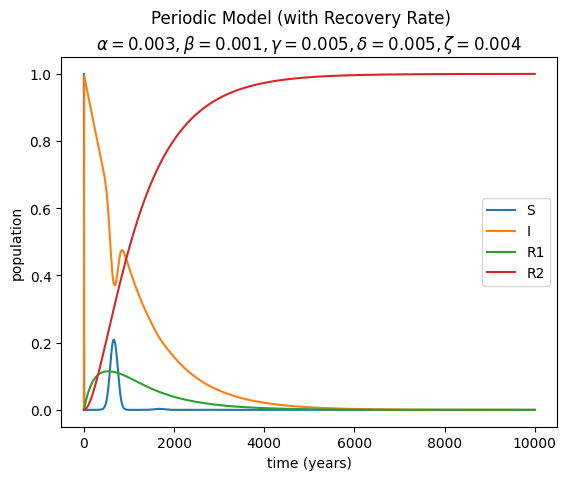

In [ ]:
initial = [4000, 1, 0, 0]
alpha1, beta, gamma, delta, zeta, pi = .003, .001, .005, .005, .004, .005
sol = solve_ivp(disease_model_periodic, t_span=[0, 10000], y0=initial, t_eval=np.linspace(0, 10000, 1000), args=[[alpha1, beta, gamma, delta, zeta, pi]])
t_vals = np.linspace(0, 10000, 1000)

plt.plot(t_vals, sol.y[0] / sum(initial), label='S')
plt.plot(t_vals, sol.y[1] / sum(initial), label="I")
plt.plot(t_vals, sol.y[2] / sum(initial), label="R1")
plt.plot(t_vals, sol.y[3] / sum(initial), label="R2")
plt.suptitle("Periodic Model (with Recovery Rate)")
plt.title(rf"$\alpha = {alpha1}, \beta = {beta}, \gamma = {gamma}, \delta = {delta}, \zeta = {zeta}$")
plt.xlabel("time (years)")
plt.ylabel("population")
# plt.ylim(0, 100)
plt.legend()
# plt.savefig("figures/PeriodicModel_withRecovery2_steady.png")

### Model with Vaccine and Recovered Class

We will let $\zeta$ from before now represent the vaccination rate. This models if a proportion of infected frogs is pulled out every time step and is cured and administered the vaccine.

In [172]:
def model_with_vaccine_old(t, y, params=[.6e1, .2e1, .01e1, .5e1, .5e1, .5e1]):
    S, I, V, R1, R2 = y
    alpha, gamma, eta, zeta, beta, delta = params

    # introduce periodic seasonal transmission
    sigma = 5    # amplitude of seasonal variation in transmission
    # alpha = alpha1*(1 + sigma*np.cos(2*np.pi*t))
    
    dy = [
        -alpha*I*S - gamma*I*R1 + eta*V,             # dS
        alpha*I*S + gamma*I*R1 - zeta*I - beta*I,    # dI
        zeta*I - eta*V,                              # dV
        beta*I - delta*R1,                           # dR1
        delta*R1                                     # dR2
    ]
    return dy

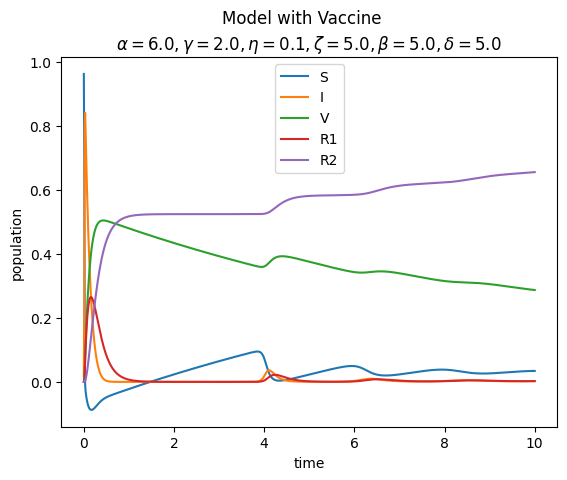

In [ ]:
initial = [50, 1, 1, 0, 0]
N = sum(initial)
alpha, gamma, eta, zeta, beta, delta = .6e1, .2e1, .01e1, .5e1, .5e1, .5e1
sol = solve_ivp(model_with_vaccine_old, t_span=[0, 10], y0=[50, 1, 0, 0, 0], t_eval=np.linspace(0, 10, 1000), args=[[alpha, gamma, eta, zeta, beta, delta]])
t_vals = np.linspace(0, 10, 1000)
plt.plot(sol.t, sol.y[0] / N, label='S')
plt.plot(sol.t, sol.y[1] / N, label="I")
plt.plot(sol.t, sol.y[2] / N, label="V")
plt.plot(sol.t, sol.y[3] / N, label="R1")
plt.plot(sol.t, sol.y[4] / N, label="R2")
plt.suptitle("Model with Vaccine")
plt.title(fr"$\alpha = {alpha}, \gamma = {gamma}, \eta = {eta}, \zeta = {zeta}, \beta = {beta}, \delta = {delta}$")
plt.xlabel("time")
plt.ylabel("population")
# plt.ylim(0, 100)
plt.legend()
# plt.savefig("figures/ModelWithVaccine.png")

### Fixed some things

In [122]:
def model_with_vaccine(t, y, params=[.09, .005, .001, .004, .001, .005]):
    S, I, V, R1, R2 = y
    alpha1, gamma, eta, zeta, beta, delta = params

    # introduce periodic seasonal transmission
    sigma = 6    # amplitude of seasonal variation in transmission
    alpha = alpha1*(1 + sigma*np.cos(2*np.pi*t))
    
    dy = [
        -alpha*I*S - gamma*I*R1 + eta*V - zeta*S*(sum(y) - (V + R1 + R2)),    # dS
        alpha*I*S + gamma*I*R1 - zeta*I*(sum(y) - (V + R1 + R2)) - beta*I,    # dI
        zeta*(I + S)*(sum(y) - (V + R1 + R2)) - eta*V,                        # dV
        beta*I - delta*R1,                             # dR1
        delta*R1                                       # dR2
    ]
    return dy

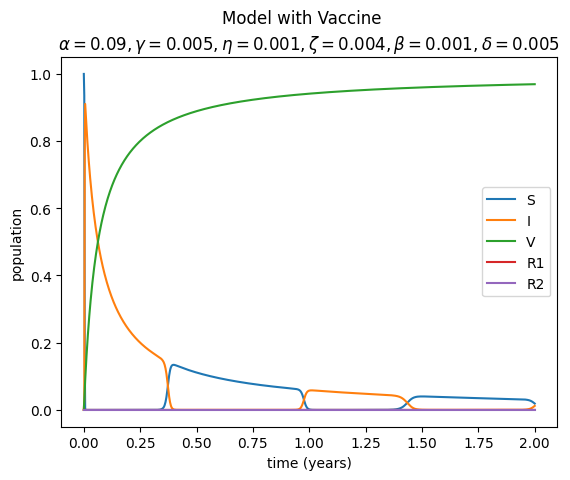

In [ ]:
initial = [4000, 1, 1, 0, 0]
alpha, gamma, eta, zeta, beta, delta = .09, .005, .001, .004, .001, .005
sol = solve_ivp(model_with_vaccine, t_span=[0, 2], y0=initial, t_eval=np.linspace(0, 2, 1000), args=[[alpha, gamma, eta, zeta, beta, delta]])
t_vals = np.linspace(0, 2, 1000)
plt.plot(sol.t, sol.y[0] / sum(initial), label='S')
plt.plot(sol.t, sol.y[1] / sum(initial), label="I")
plt.plot(sol.t, sol.y[2] / sum(initial), label="V")
plt.plot(sol.t, sol.y[3] / sum(initial), label="R1")
plt.plot(sol.t, sol.y[4] / sum(initial), label="R2")
# plt.plot([0, 1], [0, 0], c='k')
plt.suptitle(fr"Model with Vaccine")
plt.title(fr"$\alpha = {alpha}, \gamma = {gamma}, \eta = {eta}, \zeta = {zeta}, \beta = {beta}, \delta = {delta}$")
plt.xlabel("time (years)")
plt.ylabel("population")
# plt.ylim(0, 100)
plt.legend()
# plt.savefig("figures/ModelWithVaccine_take3.png")